In [2]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
# Loading the data into a dataframe
alzheimers_raw_df = pd.read_csv("alzheimers_disease_data.csv")

### Patient Information

#### Patient ID
* **PatientID**: A unique identifier assigned to each patient (4751 to 6900).

#### Demographic Details
* **Age**: The age of the patients from 60 to 90 years.
* **Gender**: Gender of the patients, where 0 represents Male and 1 represents Female.
* **Ethnicity**: The ethnicity of the patients, coded as follows:
* 0: Caucasian
* 1: African American
* 2: Asian
* 3: Other
* **EducationLevel**: The education level of the patients coded as follows:
* 0: None
* 1: High School
* 2: Bachelor's
* 3: Higher
#### Lifestyle Factors
* **BMI**: Body Mass Index of the patients, ranging from 15 to 40.
* **Smoking**: Smoking status, where 0 indicates No and 1 indicates Yes.
* **AlcoholConsumption**: Weekly alcohol consumption in units, ranging from 0 to 20.
* **PhysicalActivity**: Weekly physical activity in hours, ranging from 0 to 10.
* **DietQuality**: Diet quality score, ranging from 0 to 10.
* **SleepQuality**: Sleep quality score, ranging from 4 to 10.
### Medical History
* **FamilyHisoryAlzheimers**: Family history of Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.
* **CardiovascularDisease**: Presence of cardiovascular disease, where 0 indicates No and 1 indicates Yes.
* **Diabetes**: Presence of diabetes, where 0 indicates No and 1 indicates Yes.
* **Depression**: Presence of depression, where 0 indicates No and 1 indicates Yes.
* **HeadInjury**: History of head injury, where 0 indicates No and 1 indicates Yes.
* **Hypertension**: Presence of hypertension where 0 indicates No and 1 indicates Yes.
### Clinical Measurements
* **SystolicBP**: Sysolic blood pressure, ranging from 90 to 180 mmHg.
* **DiastolicBP**: Diastolic blood pressure, ranging from 60 to 120 mmHg.
* **ChloesterolTotal**: Total cholesterol levels, ranging from 150 to 300 mg/dL.
* **CholesterolLDL**: Low-density lipoprotein cholesterol levels, ranging from 50 to 200 mg/dL.
* **CholesterolHDL**: High-density lipoprotein cholesterol levels, ranging from 20 to 100 mg/dL.
* **CholesterolTriglycerides**: Triglycerides levels, ranging from 50 to 400 mg/dL.
### Cognitive and Functional Assessments
* **MMSE**: Mini-Mental State Examination score, ranging from 0 to 30. Lower scores indicate cognitive impairment.
* **FunctionalAssessment**: Functional assessment score, ranging from 0 to 10. Lower scores indicate greater impairment.
* **MemoryComplaints**: Presence of memory complaints, where 0 indicates No and 1 indicates Yes.
* **BehavioralProblems**: Presence of behavioral problems, where 0 indicates No and 1 indicates Yes.
* **ADL**: Activities of Daily Living score, ranging from 0 to 10. Lower scores indicate greater impairment.
### Symptoms
* **Confusion**: Presence of confusion, where 0 indicates No and 1 indicates Yes.
* **Disorientation**: Presence of disorientation, where 0 indicates No and 1 indicates Yes.
* **PersonalityChanges**: Presence of personality changes, where 0 indicates No and 1 indicates Yes.
* **DifficultyCompletingTasks**: Presence of difficulty completing tasks, where 0 indicates No and 1 indicates Yes.
* **Forgetfulness**: Presence of forgetfulness, where 0 indicates No and 1 indicates Yes.
### Diagnosis Information
* **Diagnosis**: Diagnosis status for Alzheimer's Disease, where 0 indicates No and 1 indicates Yes.
### Confidential Information
* **DoctorInCharge**: This column contains confidential information about the doctor in charge, with "XXXConfid" as the value for all patients.

In [6]:
alzheimers_raw_df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [8]:
alzheimers_raw_df.shape

(2149, 35)

In [10]:
alzheimers_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [12]:
alzheimers_raw_df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
# Making a copy of the dataframe to work with
alz_work_df = alzheimers_raw_df.copy()

In [16]:
alz_work_df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [18]:
alz_work_df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge'],
      dtype='object')

## EDA

In [21]:
sns.set_style("darkgrid")

Text(0, 0.5, 'Count')

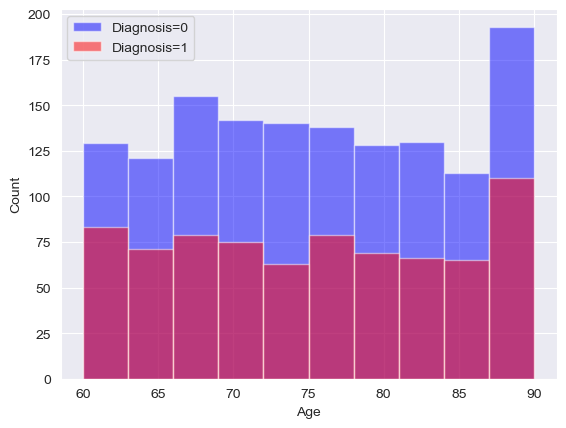

In [23]:
plt.hist(alz_work_df[alz_work_df["Diagnosis"]==0]["Age"], color="blue",label='Diagnosis=0',alpha=0.5)
plt.hist(alz_work_df[alz_work_df["Diagnosis"]==1]["Age"], color="red",label='Diagnosis=1',alpha=0.5)
plt.legend()
plt.xlabel('Age')
plt.ylabel("Count")

In [25]:
# Dropping unnecessary columns
alz_work_df.drop(["PatientID", "DoctorInCharge"],axis=1,inplace=True)

In [27]:
alz_work_df.columns

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis'],
      dtype='object')

# Standardizing The Variable

Because the variables differ in the magnitude of their scales, we will standardize the data to bring them all to a similar scale.
This will make it easier for the machine learning model to fit to the data and make accurate predictions.  
We will be using the StandardScaler module from the scikit learn library

In [30]:
# Importing the StandardScaler module
from sklearn.preprocessing import StandardScaler

In [32]:
# Creating an instance of the StandardScaler Object
scaler = StandardScaler()

In [34]:
# Fitting the scaler object to the features
scaler.fit(alz_work_df.drop("Diagnosis", axis=1))

StandardScaler()

In [36]:
# Transforming the features and storing them in the scaled_features variable
scaled_features = scaler.transform(alz_work_df.drop("Diagnosis", axis=1))

In [38]:
# Creating a list of column names for the features
alz_work_df.columns[:-1]

Index(['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking',
       'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness'],
      dtype='object')

In [40]:
# Creating a dataframe for the scaled features
alz_df_feat = pd.DataFrame(scaled_features, columns=alz_work_df.columns[:-1])

In [42]:
alz_df_feat

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
0,-0.212368,-1.012644,-0.700408,0.788833,-0.655225,-0.636784,0.565923,0.492525,-1.253593,1.119918,...,0.779037,0.497506,-0.512477,-0.431257,-1.104434,-0.508131,-0.433531,-0.421348,2.302619,-0.657048
1,1.567757,-1.012644,-0.700408,-1.422782,-0.114751,-0.636784,-0.954895,0.945093,-1.538442,0.056836,...,0.680297,0.704907,-0.512477,-0.431257,-0.810601,-0.508131,-0.433531,-0.421348,-0.434288,1.521959
2,-0.212368,-1.012644,2.311955,-0.316974,-1.366428,-0.636784,1.653006,1.023896,-1.088855,1.487380,...,-0.859222,0.281813,-0.512477,-0.431257,0.724491,-0.508131,2.306640,-0.421348,2.302619,-0.657048
3,-0.101111,0.987514,-0.700408,-0.316974,0.851625,1.570391,0.376930,1.227995,0.839804,0.760833,...,-0.088723,1.343346,-0.512477,2.318805,0.508044,-0.508131,-0.433531,-0.421348,-0.434288,-0.657048
4,1.567757,-1.012644,-0.700408,-1.422782,-0.961607,-0.636784,1.461793,0.486696,-1.443293,-0.824566,...,-0.143712,0.333665,-0.512477,-0.431257,-1.684679,-0.508131,-0.433531,2.373334,2.302619,-0.657048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,-1.547463,-1.012644,-0.700408,-0.316974,1.589030,-0.636784,-1.472807,-0.304649,0.537127,0.274767,...,-1.574000,-1.674022,-0.512477,-0.431257,-0.166194,1.967998,-0.433531,-0.421348,-0.434288,-0.657048
2145,0.010147,-1.012644,-0.700408,0.788833,-1.357833,-0.636784,1.516149,-1.246106,-0.718090,0.853112,...,-0.963527,1.247350,-0.512477,2.318805,1.431627,-0.508131,-0.433531,-0.421348,-0.434288,-0.657048
2146,0.232663,-1.012644,-0.700408,-0.316974,-1.687864,-0.636784,-0.945836,1.738405,1.075131,-0.726886,...,0.261971,-1.074634,-0.512477,-0.431257,0.018099,-0.508131,-0.433531,-0.421348,-0.434288,-0.657048
2147,0.343921,0.987514,2.311955,-0.316974,-1.712334,-0.636784,-0.237109,0.502036,-1.282402,0.721313,...,-1.245437,0.032446,-0.512477,-0.431257,-0.406078,-0.508131,-0.433531,-0.421348,-0.434288,1.521959


# Train Test Split

We will now create our training and testing data for both the features and target column.

In [45]:
# Importing train_test_split
from sklearn.model_selection import train_test_split

In [47]:
# Creating X and y variables
# X represents the features which in this case are the scaled features
X = alz_df_feat
# y represents the target column
y = alz_work_df["Diagnosis"]

In [49]:
# Splitting the data into traing and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100)

# Training a Logistic Regression Model

We will now train a Logistic Regression model on the training data

In [52]:
# Importing the LogisticRegression model
from sklearn.linear_model import LogisticRegression

In [54]:
# Creating an instance of the LogisticRegression object as logmodel
logmodel = LogisticRegression()

In [56]:
# Fitting the model to the training data
logmodel.fit(X_train,y_train)

LogisticRegression()

# Predicting and Evaluating a Logistic Regression Model

We will now make predictions off of our test data and then evaluate the model

In [59]:
# Making predictions based on the test data
predictions = logmodel.predict(X_test)

In [61]:
# Importing modules for evaluation
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [63]:
# Evaluating the model
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

[[398  43]
 [ 74 130]]
              precision    recall  f1-score   support

           0       0.84      0.90      0.87       441
           1       0.75      0.64      0.69       204

    accuracy                           0.82       645
   macro avg       0.80      0.77      0.78       645
weighted avg       0.81      0.82      0.81       645



In [65]:
print(f"Accuracy: {accuracy_score(y_test,predictions)*100:.2f}%")

Accuracy: 81.86%


The results obtained by the Logistic Regression model was good. But let us see whether we can improve by using a different model

# Training a Decison Tree Model

We will now train a different model which is the Decision Tree Model to see whether we will get better results

In [69]:
# Importing the DecisionTreeClassifier module
from sklearn.tree import DecisionTreeClassifier

In [71]:
# Creating an instance of the DecisionTreeClassifier object as dtree
dtree = DecisionTreeClassifier()

In [73]:
# Fitting the model to the training data
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

# Predicting and Evaluating a Decision Tree Model

We will now use our model to predict off of our test data and evaluate the model's performance

In [76]:
# Making prediction based on test data
dt_pred = dtree.predict(X_test)

In [78]:
# Evaluating the model
print(confusion_matrix(y_test,dt_pred))
print("\n")
print(classification_report(y_test,dt_pred))

[[399  42]
 [ 33 171]]


              precision    recall  f1-score   support

           0       0.92      0.90      0.91       441
           1       0.80      0.84      0.82       204

    accuracy                           0.88       645
   macro avg       0.86      0.87      0.87       645
weighted avg       0.89      0.88      0.88       645



In [80]:
print(f"Accuracy: {accuracy_score(y_test,dt_pred)*100:.2f}%")

Accuracy: 88.37%


With the use of the Decision Tree model we achieved a better score. \
But this was with a single decision tree. Let's see whether we can improve the results even further

# Training a Random Forest Model

We will now train a Random Forest Model, which is an ensemble of multiple decision trees to see whether we will obtain better results

In [84]:
# Importing the RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

In [86]:
# Creating an instance of the RandomForestClassifier 
rfc = RandomForestClassifier(n_estimators=200)

In [88]:
# Fitting the model to the training data
rfc.fit(X_train,y_train)

RandomForestClassifier(n_estimators=200)

# Precicting and Evaluating a Random Forest Model

We will now use our model to predict off of our training data and then evaluate the model's performance

In [91]:
# Predicting based on our test data
rfc_pred = rfc.predict(X_test)

In [93]:
# Evaluating the model
print(confusion_matrix(y_test,rfc_pred))
print("\n")
print(classification_report(y_test,rfc_pred))

[[429  12]
 [ 33 171]]


              precision    recall  f1-score   support

           0       0.93      0.97      0.95       441
           1       0.93      0.84      0.88       204

    accuracy                           0.93       645
   macro avg       0.93      0.91      0.92       645
weighted avg       0.93      0.93      0.93       645



In [95]:
print(f"Accuracy: {accuracy_score(y_test,rfc_pred)*100:.2f}%")

Accuracy: 93.02%


We have succeeded in improving on the model's performance. An accuracy of 92.7% is quite good.